Temporal Fusion Transformer (Darts) — Flood Forecasting
Predicts streamflow 24 hours ahead for the top-30 high flood-severity sites.
Uses darts.models.TFTModel for built-in explainability (variable importance,
attention weights). Logs all metrics, charts, and artifacts to W&B.

In [45]:
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import wandb

from darts import TimeSeries
from darts.models import TFTModel
from darts.explainability import TFTExplainer
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import EarlyStopping

from src.preprocessing.preprocessing import processor
import os
import logging

# Suppress pytorch_lightning verbosity globally
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)

In [46]:
STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg",
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

# streamflow_cfs_mean is the TARGET; the remaining dynamic features are past covariates
PAST_COV_COLS = [c for c in DYNAMIC_FEATURES if c != "streamflow_cfs_mean"]

In [47]:
wandb_config = {
    # Architecture
    "d_model": 64,
    "num_heads": 4,
    "hidden_continuous_size": 32,
    "lstm_layers": 1,
    "dropout_rate": 0.1,
    # Training
    "learning_rate": 1e-3,
    "under_predict_penalty": 2.0,
    "epochs": 5,
    "batch_size": 512,
    # Data
    "input_chunk_length": 72,
    "output_chunk_length": 24,
    "train_split": 0.8,
    "val_split": 0.9,
    "frequency": "hourly",
    "dataset": "flood-dataset-top30",
    "target": "streamflow_cfs_mean",
}

run = wandb.init(
    project="flood-forecasting",
    name="tft-darts",
    config=wandb_config,
    tags=["tft", "darts", "temporal-fusion-transformer", "top30"],
)

cfg = wandb.config
print(f"W&B run: {run.name}  |  id: {run.id}")

W&B run: tft-darts  |  id: xqpe4hei


In [48]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
# lag_window=1 disables manual lag creation — Darts handles temporal context
# via input_chunk_length. No split_time_days so each site's series is continuous
# (required for Darts TimeSeries objects).
proc_config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",  # required by processor; not used by Darts
    "train_split": cfg.train_split,
    "val_split": cfg.val_split,
    "file_path": cfg.dataset,
    "file_name": "flood_model_top30",
    "table": "wandb.flood_model_top30",
    "lag_window": 1,
    "frequency": cfg.frequency,
    "site_scaling": False,
}

pcr = processor(proc_config)
pcr.pull_wandb()

# y outputs are unused — Darts infers the target shift from output_chunk_length
train_X, val_X, test_X, _, _, _ = pcr.return_outputs()

sites_ordered = sorted(train_X["site_id"].unique().to_list())
print(f"Sites: {len(sites_ordered)} | Train rows: {len(train_X):,} | Val: {len(val_X):,} | Test: {len(test_X):,}")

wandb.log({
    "data/n_sites": len(sites_ordered),
    "data/n_past_cov_features": len(PAST_COV_COLS),
    "data/n_static_features": len(STATIC_FEATURES),
})

wandb: Downloading large artifact 'flood-dataset-top30:latest', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.2 (776.4MB/s)


Starting preprocessing: 4,818,417 rows, 31 columns
After lag null removal: 3,412,815 rows, 28 features
Splitting by time...
Train: 2,730,227 | Val: 341,296 | Test: 341,292
Scaling features and targets...
Scaling complete.
Sites: 34 | Train rows: 2,730,227 | Val: 341,296 | Test: 341,292


In [49]:
# ── Darts TimeSeries conversion ────────────────────────────────────────────────
# Per site: target = scaled streamflow_cfs_mean
#           past_covariates = all other scaled dynamic features
#           static_covariates attached to target TimeSeries

def to_darts(
    X_df: pl.DataFrame,
) -> tuple[list[TimeSeries], list[TimeSeries]]:
    """Convert a scaled Polars DataFrame to per-site Darts TimeSeries lists."""
    target_list: list[TimeSeries] = []
    past_cov_list: list[TimeSeries] = []

    for site in sorted(X_df["site_id"].unique().to_list()):
        site_pd = (
            X_df.filter(pl.col("site_id") == site)
            .sort("observation_hour")
            .to_pandas()
        )
        site_pd["observation_hour"] = pd.to_datetime(site_pd["observation_hour"])
        site_pd = site_pd.set_index("observation_hour").drop(columns=["site_id"])

        # Target: scaled streamflow_cfs_mean
        target_ts = TimeSeries.from_dataframe(
            site_pd[["streamflow_cfs_mean"]],
            fill_missing_dates=True,
            fillna_value=0.0,  # z-score mean=0 is a reasonable gap fill for scaled data
            freq="h",
        )

        # Attach static covariates (time-invariant — take first row)
        static_vals = pd.DataFrame(
            {col: [float(site_pd[col].iloc[0])] for col in STATIC_FEATURES}
        )
        target_ts = target_ts.with_static_covariates(static_vals)

        # Past covariates: all dynamic features except the target
        past_cov_ts = TimeSeries.from_dataframe(
            site_pd[PAST_COV_COLS],
            fill_missing_dates=True,
            fillna_value=0.0,
            freq="h",
        )

        target_list.append(target_ts)
        past_cov_list.append(past_cov_ts)

    return target_list, past_cov_list


print("Converting splits to Darts TimeSeries...")
train_series, train_past_covs = to_darts(train_X)
val_series,   val_past_covs   = to_darts(val_X)
test_series,  test_past_covs  = to_darts(test_X)
print(f"Done. Example train series length: {len(train_series[0])} steps")

Converting splits to Darts TimeSeries...
Done. Example train series length: 120597 steps


In [50]:
# ── Model ─────────────────────────────────────────────────────────────────────
TEST_RUN = True

class AsymmetricMSELoss(nn.Module):
    """MSE with configurable penalty on under-predictions (residual > 0)."""

    def __init__(self, under_penalty: float = 2.0):
        super().__init__()
        self.under_penalty = float(under_penalty)

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        error = target - pred
        weight = torch.where(error > 0, self.under_penalty, 1.0)
        return (weight * error.pow(2)).mean()


# Verify GPU
use_gpu = torch.cuda.is_available()
device_name = torch.cuda.get_device_name(0) if use_gpu else "CPU"
print(f"Device: {'GPU' if use_gpu else 'CPU'} — {device_name}")
print(f"CUDA version: {torch.version.cuda}")

from pytorch_lightning.callbacks import TQDMProgressBar

wandb_logger = WandbLogger(experiment=run, log_model=False)

tft = TFTModel(
    input_chunk_length=cfg.input_chunk_length,
    output_chunk_length=cfg.output_chunk_length,
    hidden_size=cfg.d_model,
    lstm_layers=cfg.lstm_layers,
    num_attention_heads=cfg.num_heads,
    dropout=cfg.dropout_rate,
    hidden_continuous_size=cfg.hidden_continuous_size,
    loss_fn=AsymmetricMSELoss(cfg.under_predict_penalty),
    optimizer_kwargs={"lr": cfg.learning_rate},
    batch_size=cfg.batch_size,
    use_static_covariates=True,
    add_relative_index=True,
    pl_trainer_kwargs={
        "max_epochs": cfg.epochs,
        "logger": wandb_logger,
        "callbacks": [
            TQDMProgressBar(refresh_rate=20),
        ],
        "accelerator": "gpu" if use_gpu else "cpu",
        "devices": 1,
        "enable_progress_bar": True,
        **({"fast_dev_run": 1} if TEST_RUN else {}),
    },
)

print(f"\nTFTModel ready | lookback: {cfg.input_chunk_length}h | horizon: {cfg.output_chunk_length}h")

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Device: GPU — NVIDIA GeForce RTX 4080
CUDA version: 12.4

TFTModel ready | lookback: 72h | horizon: 24h


In [51]:
# ── Train ─────────────────────────────────────────────────────────────────────
tft.fit(
    series=train_series,
    past_covariates=train_past_covs,
    val_series=val_series,
    val_past_covariates=val_past_covs,
    verbose=True,
)

total_params = sum(p.numel() for p in tft.model.parameters())
wandb.log({"model/total_params": total_params})
print(f"Training complete |     Parameters: {total_params:,}")

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ criterion                         │ AsymmetricMSELoss                │      0 │ train │     0 │
│ 1  │ train_criterion                   │ AsymmetricMSELoss                │      0 │ train │     0 │
│ 2  │ val_criterion                     │ AsymmetricMSELoss                │      0 │ train │     0 │
│ 3  │ train_metrics                     │ MetricCollection                 │      0 │ train │     0 │
│ 4  │ val_metrics                       │ MetricCollection                 │      0 │ train │     0 │
│ 5  │ input_embeddings                  │ _MultiEmbedding                  │      0 │ train │     0 │
│ 6  │ static_covariates_vsn             │ _VariableSelectionNetwork        │  101 K │ train │     0 │
│ 7  │ encoder_vsn                       │ _VariableSelectionNetwork        │  109 K │ train │     0 │
│ 8  │ decoder_vsn                       │ _VariableSelectionNetwork        │  6.7 K │ train │     0 │
│ 9  │ static_context_grn                │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_hidden_encoder_grn │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ static_context_cell_encoder_grn   │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 12 │ static_context_enrichment         │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 13 │ lstm_encoder                      │ LSTM                             │ 33.3 K │ train │     0 │
│ 14 │ lstm_decoder                      │ LSTM                             │ 33.3 K │ train │     0 │
│ 15 │ post_lstm_gan                     │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 16 │ static_enrichment_grn             │ _GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 17 │ multihead_attn                    │ _InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 18 │ post_attn_gan                     │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 19 │ feed_forward_block                │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 20 │ pre_output_gan                    │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 21 │ output_layer                      │ Linear                           │     65 │ train │     0 │
└────┴───────────────────────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 424 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 424 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 594                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 0: 100%|██████████| 1/1 [00:01<00:00,  0.70it/s, train_loss=0.822, val_loss=0.395]
Training complete |     Parameters: 424,549


In [52]:
# ── Evaluation: rolling 24h-ahead forecasts over the test set ─────────────────

if TEST_RUN:
    # Smoke test: 1 site, just enough steps for a handful of predictions
    _n = cfg.input_chunk_length + cfg.output_chunk_length * 3
    eval_series    = [test_series[0][:_n]]
    eval_past_covs = [test_past_covs[0][:_n]]
    print(f"TEST_RUN: evaluating on 1 site, {_n} steps")
else:
    eval_series    = test_series
    eval_past_covs = test_past_covs

print("Running historical forecasts on test set...")
historical_preds = tft.historical_forecasts(
    series=eval_series,
    past_covariates=eval_past_covs,
    forecast_horizon=cfg.output_chunk_length,
    stride=cfg.output_chunk_length,
    start=cfg.input_chunk_length,
    retrain=False,
    last_points_only=False,
    enable_optimization=False,
    verbose=False,
)

print(f"Forecasts generated for {len(historical_preds)} series")

TEST_RUN: evaluating on 1 site, 144 steps
Running historical forecasts on test set...
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 60.21it/s]
Forecasts generated for 1 series


In [53]:
# ── Postprocessing: inverse transform + global metrics ────────────────────────
from darts import concatenate as darts_concatenate

pred_scaled_all:   list[float] = []
actual_scaled_all: list[float] = []
test_site_ids:     list[str]   = []

all_test_sites = sorted(test_X["site_id"].unique().to_list())
# In TEST_RUN only 1 site was evaluated; align site labels to eval_series length
eval_site_ids = all_test_sites[:len(historical_preds)]

for i, pred_ts in enumerate(historical_preds):
    site = eval_site_ids[i]
    actual_ts = eval_series[i]

    # last_points_only=False returns a list of TimeSeries per series; concatenate them
    if isinstance(pred_ts, list):
        pred_ts = darts_concatenate(pred_ts)

    actual_slice = actual_ts.slice(pred_ts.start_time(), pred_ts.end_time())

    pred_vals   = pred_ts.values().flatten()
    actual_vals = actual_slice.values().flatten()

    min_len = min(len(pred_vals), len(actual_vals))
    pred_scaled_all.extend(pred_vals[:min_len].tolist())
    actual_scaled_all.extend(actual_vals[:min_len].tolist())
    test_site_ids.extend([site] * min_len)

pred_scaled   = np.array(pred_scaled_all,   dtype="float32")
actual_scaled = np.array(actual_scaled_all, dtype="float32")
test_site_ids = np.array(test_site_ids)

# Inverse-transform to CFS
pred_cfs = pcr.target_scaler.inverse_transform(
    torch.tensor(pred_scaled).reshape(-1, 1)
).numpy().flatten()

actual_cfs = pcr.target_scaler.inverse_transform(
    torch.tensor(actual_scaled).reshape(-1, 1)
).numpy().flatten()

mae_cfs  = float(np.abs(pred_cfs - actual_cfs).mean())
rmse_cfs = float(np.sqrt(np.mean((pred_cfs - actual_cfs) ** 2)))
nse      = float(1 - (
    np.sum((actual_cfs - pred_cfs) ** 2) /
    np.sum((actual_cfs - actual_cfs.mean()) ** 2)
))
bias_pct = float((pred_cfs.mean() - actual_cfs.mean()) / actual_cfs.mean() * 100)

print(f"{'Metric':<12} {'Value':>12}")
print("-" * 26)
print(f"{'MAE':<12} {mae_cfs:>10.1f} CFS")
print(f"{'RMSE':<12} {rmse_cfs:>10.1f} CFS")
print(f"{'NSE':<12} {nse:>12.4f}")
print(f"{'Bias':<12} {bias_pct:>10.1f} %")

wandb.log({
    "test/mae_cfs":  mae_cfs,
    "test/rmse_cfs": rmse_cfs,
    "test/nse":      nse,
    "test/bias_pct": bias_pct,
})
# ── Save predictions for offline chart regeneration ───────────────────────────
import os
_cwd         = os.getcwd()
_results_dir = os.path.join(_cwd, "reports", "results")
_figures_dir = os.path.join(_cwd, "reports", "figures")
os.makedirs(_results_dir, exist_ok=True)
os.makedirs(_figures_dir, exist_ok=True)

pl.DataFrame({
    "site_id":    test_site_ids.tolist(),
    "actual_cfs": actual_cfs.tolist(),
    "pred_cfs":   pred_cfs.tolist(),
}).write_parquet(os.path.join(_results_dir, "predictions.parquet"))
print(f"Saved predictions  -> {_results_dir}")

Metric              Value
--------------------------
MAE               726.8 CFS
RMSE              819.9 CFS
NSE               -3.8328
Bias              102.2 %
Saved predictions  -> d:\Flood-Forecasting\notebooks\model_training\tft\reports\results


In [54]:
# ── Per-site metrics table ────────────────────────────────────────────────────

site_rows = []
for site in np.unique(test_site_ids):
    mask = test_site_ids == site
    a = actual_cfs[mask]
    p = pred_cfs[mask]
    site_mae  = float(np.abs(p - a).mean())
    site_rmse = float(np.sqrt(np.mean((p - a) ** 2)))
    site_nse  = float(
        1 - (np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2))
        if a.std() > 0 else float("nan")
    )
    site_rows.append({
        "site_id":            site,
        "actual_mean_cfs":    round(float(a.mean()), 1),
        "predicted_mean_cfs": round(float(p.mean()), 1),
        "mae_cfs":            round(site_mae, 1),
        "rmse_cfs":           round(site_rmse, 1),
        "nse":                round(site_nse, 4),
    })
    print(
        f"Site {site}: actual={a.mean():.1f}  pred={p.mean():.1f}  "
        f"MAE={site_mae:.1f}  NSE={site_nse:.3f}"
    )

site_df = pl.DataFrame(site_rows)
wandb.log({
    "test/per_site_metrics": wandb.Table(
        columns=site_df.columns,
        data=site_df.to_pandas().values.tolist(),
    )
})
site_df.write_parquet(os.path.join(_results_dir, "per_site_metrics.parquet"))
print("Saved per-site metrics.")

Site 06036650: actual=711.0  pred=1437.8  MAE=726.8  NSE=-3.833
Saved per-site metrics.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 52.62it/s]


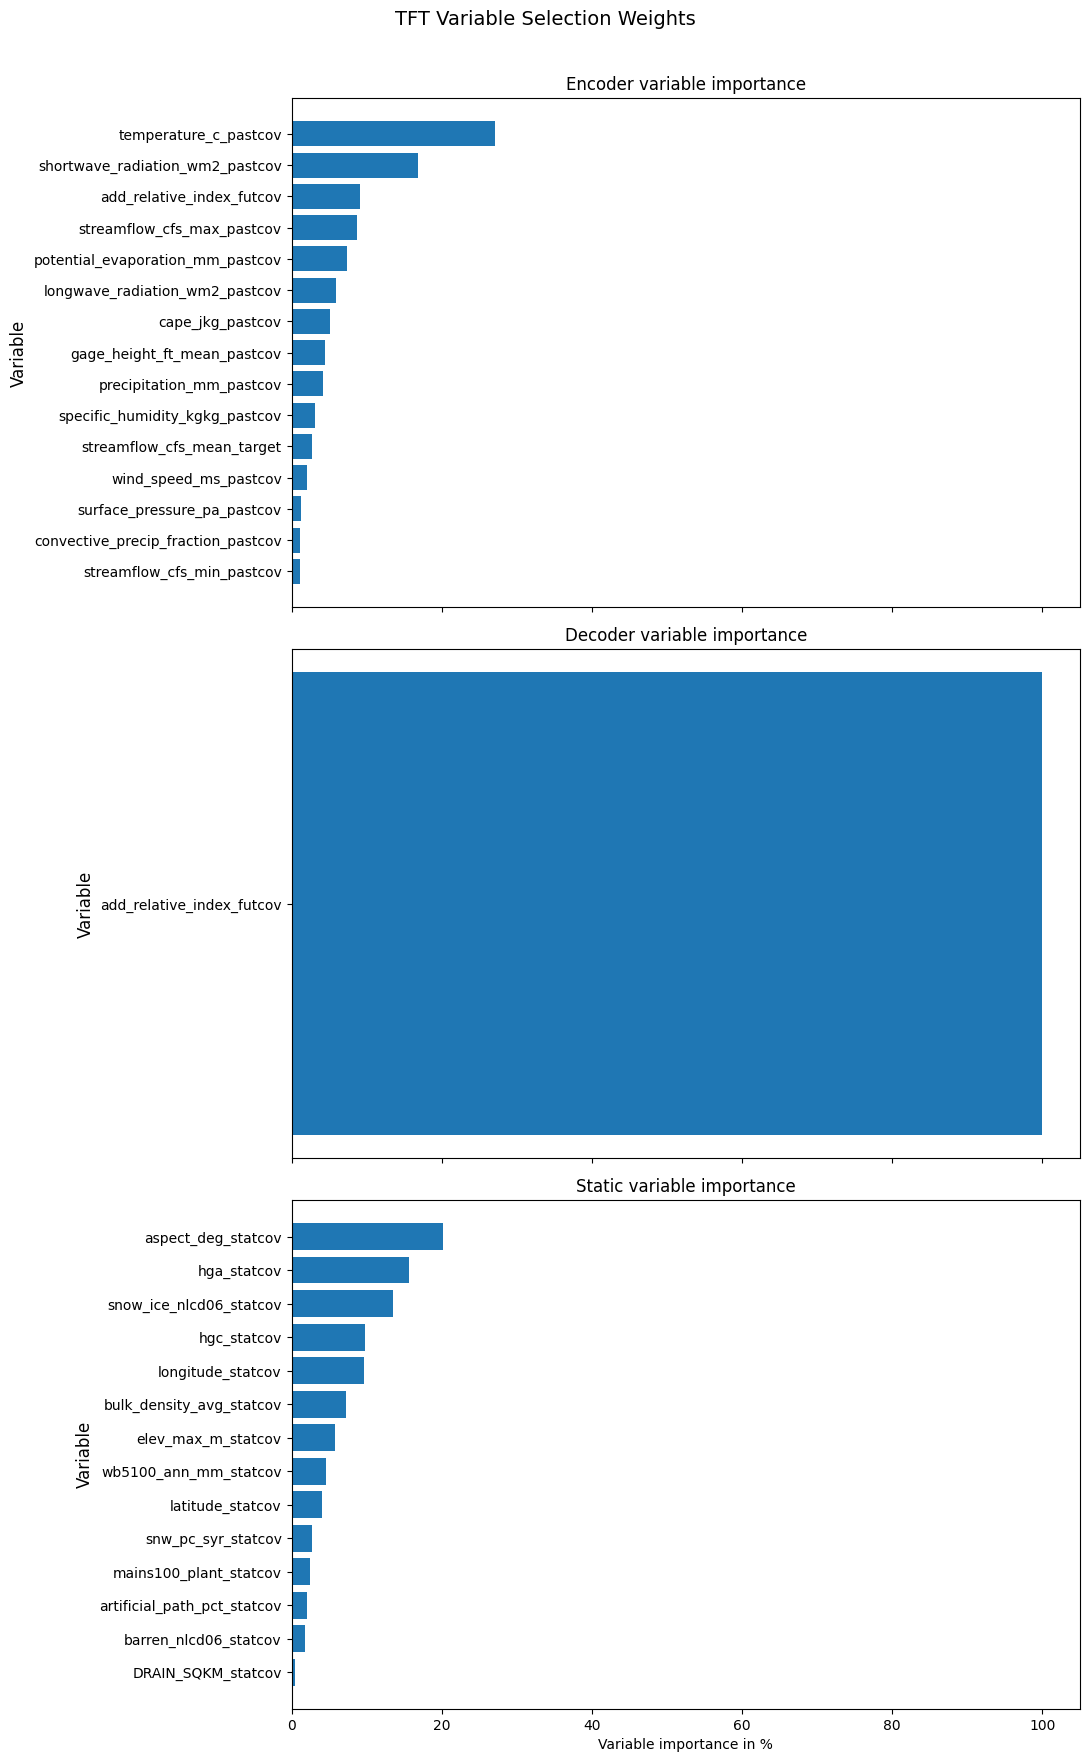

Figure 1 — encoder: 15 vars | decoder: 1 vars | static: 14 vars


In [55]:
# ── Figure 1: Variable Selection Weights ─────────────────────────────────────
# Centerpiece of the explainability story.  Dynamic figure height prevents bars
# from being squashed regardless of feature count.


_min_len = cfg.input_chunk_length + cfg.output_chunk_length

# Build explainer once; reused by Figures 2-4
explainer = TFTExplainer(
    tft,
    background_series=train_series[0][-_min_len * 2:],
    background_past_covariates=train_past_covs[0][-_min_len * 2:],
)
explanation = explainer.explain(
    foreground_series=test_series[0][-_min_len * 2:],
    foreground_past_covariates=test_past_covs[0][-_min_len * 2:],
)

enc_imp = explanation.get_encoder_importance()
dec_imp = explanation.get_decoder_importance()
stc_imp = explanation.get_static_covariates_importance()

# Save importance tables
enc_imp.to_csv(os.path.join(_results_dir, "encoder_importance.csv"))
dec_imp.to_csv(os.path.join(_results_dir, "decoder_importance.csv"))
if not stc_imp.empty:
    stc_imp.to_csv(os.path.join(_results_dir, "static_importance.csv"))

# Dynamic height: ~0.40 in per feature bar + 1.8 in subplot overhead
n_enc    = len(enc_imp.columns)
n_dec    = len(dec_imp.columns)
n_stc    = 0 if stc_imp.empty else len(stc_imp.columns)
n_panels = 3 if not stc_imp.empty else 2
fig_h    = max(n_panels * 4.0, (n_enc + n_dec + n_stc) * 0.40 + n_panels * 1.8)

fig_var = explainer.plot_variable_selection(
    explanation, fig_size=(11, fig_h), show_plot=False
)
fig_var.suptitle("TFT Variable Selection Weights", fontsize=14, y=1.01)
fig_var.tight_layout()
fig_var.savefig(
    os.path.join(_figures_dir, "fig1_variable_selection.png"),
    dpi=150, bbox_inches="tight",
)
wandb.log({"explainability/variable_selection": wandb.Image(fig_var)})
plt.show()
print(f"Figure 1 — encoder: {n_enc} vars | decoder: {n_dec} vars | static: {n_stc} vars")

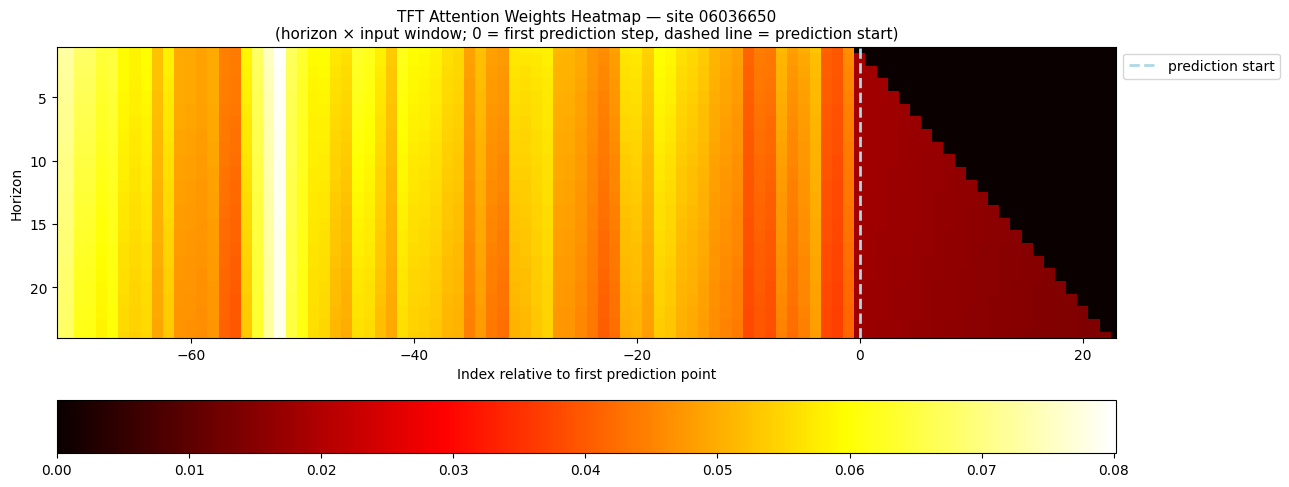

Figure 2 saved.


In [56]:
# ── Figure 2: Attention Weights Heatmap ──────────────────────────────────────
# Shows *when* in the 72-h input window the model looks for each forecast step.
# x-axis: relative index (−ICL … OCL−1), 0 = first prediction step
# y-axis: forecast horizon (1 … output_chunk_length)

_site_label = all_test_sites[0]

attn_ts = explanation.get_attention()   # TimeSeries shape (ICL+OCL, n_horizons)
attn_ts.to_dataframe().to_csv(os.path.join(_results_dir, "attention_weights.csv"))

fig_attn, ax_attn = plt.subplots(figsize=(13, 5))
explainer.plot_attention(
    explanation, plot_type="heatmap", ax=ax_attn, show_plot=False
)
ax_attn.set_title(
    f"TFT Attention Weights Heatmap — site {_site_label}\n"
    "(horizon × input window; 0 = first prediction step, dashed line = prediction start)",
    fontsize=11,
)
fig_attn.tight_layout()
fig_attn.savefig(
    os.path.join(_figures_dir, "fig2_attention_heatmap.png"),
    dpi=150, bbox_inches="tight",
)
wandb.log({"explainability/attention_heatmap": wandb.Image(fig_attn)})
plt.show()
print("Figure 2 saved.")


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 62.49it/s]


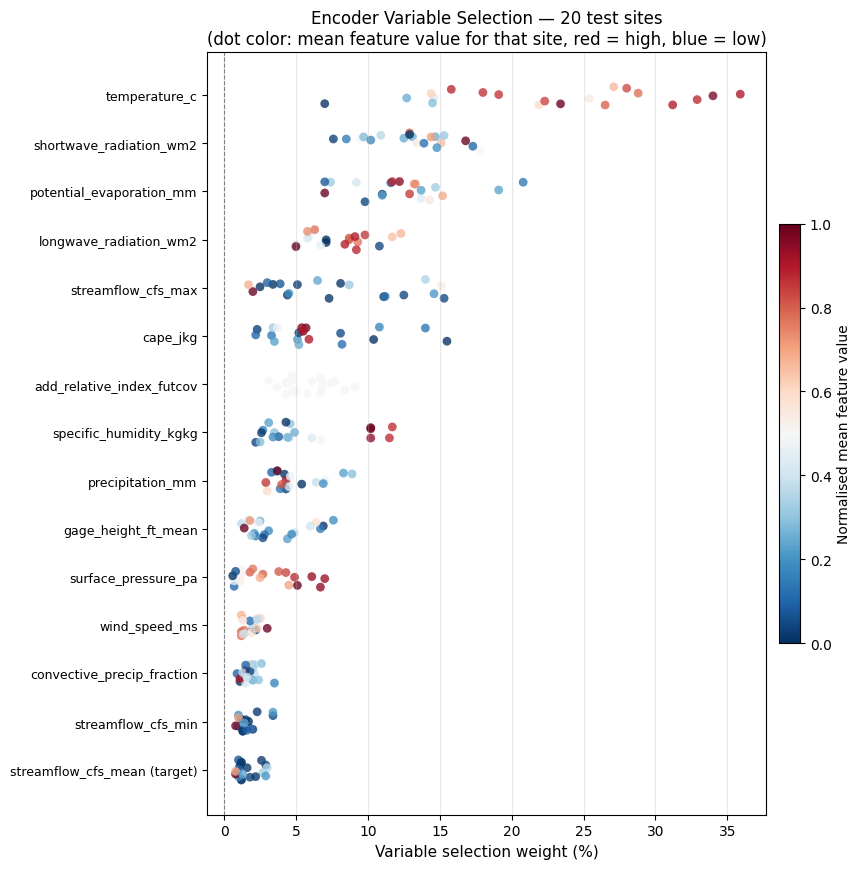

Figure 3 saved (20 sites).


In [57]:
# ── Figure 3: Variable Importance Beeswarm (cross-site) ──────────────────────
# Runs TFTExplainer.explain() over up to N test sites.
# Each dot = one test site; color = normalised mean feature value (red=high, blue=low).
# Mirrors a SHAP beeswarm but uses TFT's native variable selection weights.


N_EXPLAIN = min(len(test_series), 20)
_min_len  = cfg.input_chunk_length + cfg.output_chunk_length

explained_sites: list = []
enc_rows: list        = []

for i in range(N_EXPLAIN):
    if len(test_series[i]) < _min_len * 2:
        continue
    try:
        exp_i = explainer.explain(
            foreground_series=test_series[i][-_min_len * 2:],
            foreground_past_covariates=test_past_covs[i][-_min_len * 2:],
        )
        enc_rows.append(exp_i.get_encoder_importance())
        explained_sites.append(all_test_sites[i])
    except Exception as exc:
        print(f"  Site {i} skipped: {exc}")


enc_matrix  = pd.concat(enc_rows, ignore_index=True)   # (N, n_features)
n_explained = len(enc_matrix)

# Precompute mean feature values per site for dot coloring
ts_cov_comp = test_past_covs[0].components.tolist()

site_past_means:   dict = {}
site_target_means: dict = {}
for s in explained_sites:
    idx = all_test_sites.index(s)
    site_past_means[s]   = test_past_covs[idx][-_min_len * 2:].values().mean(axis=0)
    site_target_means[s] = float(test_series[idx][-_min_len * 2:].values().mean())

feat_val_arr: dict = {}
for col in enc_matrix.columns:
    if col.endswith("_pastcov"):
        fname = col[:-len("_pastcov")]
        if fname in ts_cov_comp:
            fi = ts_cov_comp.index(fname)
            feat_val_arr[col] = np.array([site_past_means[s][fi] for s in explained_sites])
        else:
            feat_val_arr[col] = np.full(n_explained, 0.5)
    elif col.endswith("_target"):
        feat_val_arr[col] = np.array([site_target_means[s] for s in explained_sites])
    else:
        feat_val_arr[col] = np.full(n_explained, 0.5)

# Sort by median importance (least → most)
feat_order  = enc_matrix.median().sort_values().index.tolist()
feat_labels = [
    c.replace("_pastcov", "")
     .replace("_target", " (target)")
     .replace("_statcov", " (static)")
    for c in feat_order
]

cmap      = plt.cm.RdBu_r
fig_h_bee = max(5.0, len(feat_order) * 0.44 + 2.2)
fig_bee, ax_bee = plt.subplots(figsize=(9, fig_h_bee))
np.random.seed(42)

for j, col in enumerate(feat_order):
    x_vals   = enc_matrix[col].values
    raw_vals = feat_val_arr[col]
    v_min, v_max = raw_vals.min(), raw_vals.max()
    c_norm = (
        (raw_vals - v_min) / (v_max - v_min)
        if v_max > v_min
        else np.full(n_explained, 0.5)
    )
    jitter = np.random.uniform(-0.22, 0.22, size=len(x_vals))
    ax_bee.scatter(
        x_vals, j + jitter, c=c_norm, cmap=cmap, vmin=0, vmax=1,
        alpha=0.78, s=40, linewidths=0,
    )

ax_bee.set_yticks(range(len(feat_labels)))
ax_bee.set_yticklabels(feat_labels, fontsize=9)
ax_bee.set_xlabel("Variable selection weight (%)", fontsize=11)
ax_bee.set_title(
    f"Encoder Variable Selection — {n_explained} test sites\n"
    "(dot color: mean feature value for that site, red = high, blue = low)",
    fontsize=12,
)
ax_bee.axvline(0, color="grey", lw=0.8, ls="--")
ax_bee.grid(axis="x", alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
fig_bee.colorbar(
    sm, ax=ax_bee, label="Normalised mean feature value",
    orientation="vertical", shrink=0.55, pad=0.02,
)
fig_bee.tight_layout()
fig_bee.savefig(
    os.path.join(_figures_dir, "fig3_beeswarm.png"),
    dpi=150, bbox_inches="tight",
)
wandb.log({"explainability/beeswarm": wandb.Image(fig_bee)})
plt.show()

enc_out = enc_matrix.copy()
enc_out["site_id"] = explained_sites
enc_out.to_csv(
    os.path.join(_results_dir, "cross_site_encoder_importance.csv"), index=False
)
print(f"Figure 3 saved ({n_explained} sites).")

Flood site: 06036650  |  peak CFS: 1,415
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 62.50it/s]


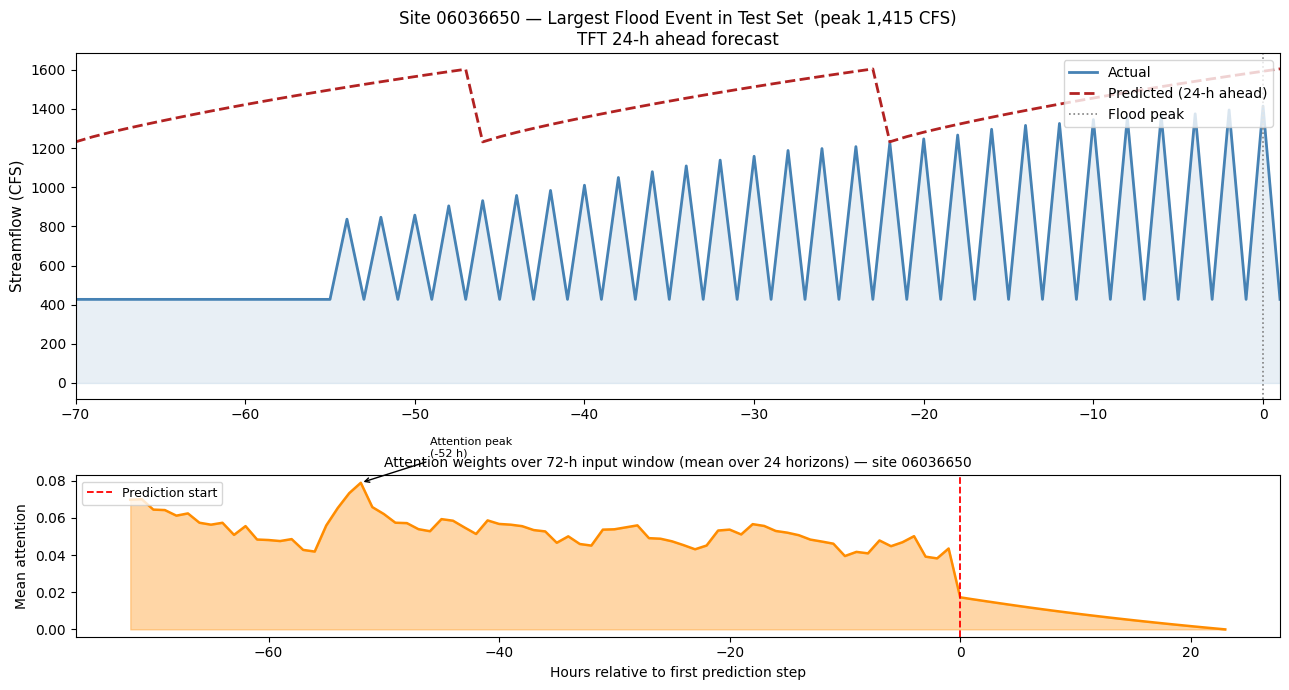

Figure 4 saved.


In [58]:
# ── Figure 4: Annotated Flood Event ──────────────────────────────────────────
# Finds the test site with the largest flood peak, plots predicted vs actual
# with the model's mean attention weights below — connecting the accuracy story
# to the interpretability story in one figure.


_flood_df = pl.DataFrame({
    "site_id":    test_site_ids.tolist(),
    "actual_cfs": actual_cfs.tolist(),
})
_peak_by_site = (
    _flood_df.group_by("site_id")
    .agg(pl.col("actual_cfs").max().alias("peak_cfs"))
    .sort("peak_cfs", descending=True)
)
flood_site = _peak_by_site["site_id"][0]
flood_peak = float(_peak_by_site["peak_cfs"][0])
print(f"Flood site: {flood_site}  |  peak CFS: {flood_peak:,.0f}")

_mask       = test_site_ids == flood_site
site_actual = actual_cfs[_mask]
site_pred   = pred_cfs[_mask]

peak_step   = int(np.argmax(site_actual))
win_start   = max(0, peak_step - 72)
win_end     = min(len(site_actual), peak_step + 49)
plot_actual = site_actual[win_start:win_end]
plot_pred   = site_pred[win_start:win_end]
peak_in_win = peak_step - win_start
x_hours     = np.arange(len(plot_actual)) - peak_in_win

# Attention for a representative test window at this site
site_idx = all_test_sites.index(flood_site)
_min_len = cfg.input_chunk_length + cfg.output_chunk_length

exp_flood = explainer.explain(
    foreground_series=test_series[site_idx][-_min_len * 2:],
    foreground_past_covariates=test_past_covs[site_idx][-_min_len * 2:],
)

attn_flood = exp_flood.get_attention()
attn_mean  = attn_flood.values().mean(axis=1)   # mean over horizons → (ICL+OCL,)
rel_idx    = np.arange(-cfg.input_chunk_length, cfg.output_chunk_length)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_flood, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(13, 7),
    gridspec_kw={"height_ratios": [3, 1.4]},
)

ax1.fill_between(x_hours, plot_actual, alpha=0.12, color="steelblue")
ax1.plot(x_hours, plot_actual, color="steelblue", lw=2.0, label="Actual")
ax1.plot(x_hours, plot_pred,   color="firebrick",  lw=2.0, ls="--",
         label="Predicted (24-h ahead)")
ax1.axvline(0, color="grey", lw=1.2, ls=":", label="Flood peak")
ax1.set_ylabel("Streamflow (CFS)", fontsize=11)
ax1.set_title(
    f"Site {flood_site} — Largest Flood Event in Test Set  "
    f"(peak {flood_peak:,.0f} CFS)\n"
    "TFT 24-h ahead forecast",
    fontsize=12,
)
ax1.legend(loc="upper right", fontsize=10)
ax1.set_xlim(x_hours[0], x_hours[-1])

ax2.fill_between(rel_idx, attn_mean, alpha=0.35, color="darkorange")
ax2.plot(rel_idx, attn_mean, color="darkorange", lw=1.8)
ax2.axvline(0, color="red", lw=1.3, ls="--", label="Prediction start")
ax2.set_xlabel("Hours relative to first prediction step", fontsize=10)
ax2.set_ylabel("Mean attention", fontsize=10)
ax2.set_title(
    f"Attention weights over {cfg.input_chunk_length}-h input window "
    f"(mean over {cfg.output_chunk_length} horizons) — site {flood_site}",
    fontsize=10,
)
ax2.legend(loc="upper left", fontsize=9)

peak_attn_pos  = int(np.argmax(attn_mean))
peak_attn_hour = rel_idx[peak_attn_pos]
ax2.annotate(
    f"Attention peak\n({peak_attn_hour:+d} h)",
    xy=(peak_attn_hour, attn_mean[peak_attn_pos]),
    xytext=(peak_attn_hour + 6, attn_mean[peak_attn_pos] * 1.18),
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
)

fig_flood.tight_layout()
fig_flood.savefig(
    os.path.join(_figures_dir, "fig4_flood_event.png"),
    dpi=150, bbox_inches="tight",
)
wandb.log({"explainability/flood_event": wandb.Image(fig_flood)})
plt.show()

pd.DataFrame({
    "hours_from_peak": x_hours.tolist(),
    "actual_cfs":      plot_actual.tolist(),
    "pred_cfs":        plot_pred.tolist(),
}).to_csv(os.path.join(_results_dir, "flood_event_prediction.csv"), index=False)
pd.DataFrame({
    "rel_hour":  rel_idx.tolist(),
    "mean_attn": attn_mean.tolist(),
}).to_csv(os.path.join(_results_dir, "flood_event_attention.csv"), index=False)
print("Figure 4 saved.")

In [59]:
# ── Save model and log as W&B artifact ────────────────────────────────────────
import os
save_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "tft_darts_model.pt")

# Temporarily clear the trainer so Darts skips the PL checkpoint step,
# which fails due to an fsspec version incompatibility.
_trainer = tft.trainer
tft.trainer = None
tft.save(save_path)
tft.trainer = _trainer

print(f"Model saved to {save_path}")

artifact = wandb.Artifact(
    name="tft-darts-model",
    type="model",
    description="Darts TFTModel trained on top-30 flood sites",
    metadata={
        "mae_cfs":  mae_cfs,
        "rmse_cfs": rmse_cfs,
        "nse":      nse,
        **dict(cfg),
    },
)
artifact.add_file(save_path)
run.log_artifact(artifact)
print("Model artifact logged to W&B.")

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
d:\Flood-Forecasting\.venv\Lib\site-packages\pytorch_lightning\loggers\wandb.py:400: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Darts model saved to d:\Flood-Forecasting\notebooks\model_training\tft\tft_darts_model.pt
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 62.50it/s]


d:\Flood-Forecasting\.venv\Lib\site-packages\darts\models\forecasting\tft_model.py:479: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if batch_size != self.batch_size_last:
d:\Flood-Forecasting\.venv\Lib\site-packages\darts\models\forecasting\tft_model.py:402: TracerWarning: Using len to get tensor shape might cause the trace to be incorrect. Recommended usage would be tensor.shape[0]. Passing a tensor of different shape might lead to errors or silently give incorrect results.
  return index.reshape(1, len(index), 1).repeat(batch_size, 1, 1)
d:\Flood-Forecasting\.venv\Lib\site-packages\darts\models\forecasting\tft_submodels.py:545: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function t

ONNX model saved to d:\Flood-Forecasting\notebooks\model_training\tft\tft_darts_model.onnx
Model artifact logged to W&B.


In [60]:
wandb.finish()

data/n_past_cov_features,▁
data/n_sites,▁
data/n_static_features,▁
model/total_params,▁
test/bias_pct,▁
test/mae_cfs,▁
test/nse,▁
test/rmse_cfs,▁
data/n_past_cov_features,13
data/n_sites,34
data/n_static_features,14
